In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:

# 1. Define the Neural Network Models
def create_model(activation='sigmoid'):
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(50, activation=activation),
        tf.keras.layers.Dense(50, activation=activation),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model


In [3]:
# 2. Setup Data
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [4]:

# 3. Define Training Function (or use model.fit)
def train_model(model, x_train, y_train, x_test, y_test, epochs=10):
    model.compile(optimizer='sgd',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    
    history = model.fit(x_train, y_train, epochs=epochs, 
                        validation_data=(x_test, y_test), verbose=1)
    return history.history

In [5]:
# Train with Sigmoid
model_sigmoid = create_model(activation='sigmoid')
history_sigmoid = train_model(model_sigmoid, x_train, y_train, x_test, y_test)

# Train with ReLU
model_relu = create_model(activation='relu')
history_relu = train_model(model_relu, x_train, y_train, x_test, y_test)

c:\Users\Admin\AppData\Roaming\uv\python\cpython-3.12.13-windows-x86_64-none\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.3168 - loss: 2.2128 - val_accuracy: 0.5024 - val_loss: 2.0732
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.5629 - loss: 1.8186 - val_accuracy: 0.6206 - val_loss: 1.5094
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6912 - loss: 1.2632 - val_accuracy: 0.7535 - val_loss: 1.0447
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7734 - loss: 0.9261 - val_accuracy: 0.8064 - val_loss: 0.8043
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8154 - loss: 0.7398 - val_accuracy: 0.8365 - val_loss: 0.6576
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8397 - loss: 0.6242 - val_accuracy: 0.8584 - val_loss: 0.5650
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8562 - loss: 0.5492 - val_accuracy: 0.8695 - val_loss: 0.5024
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8682 - loss: 0.4964 -

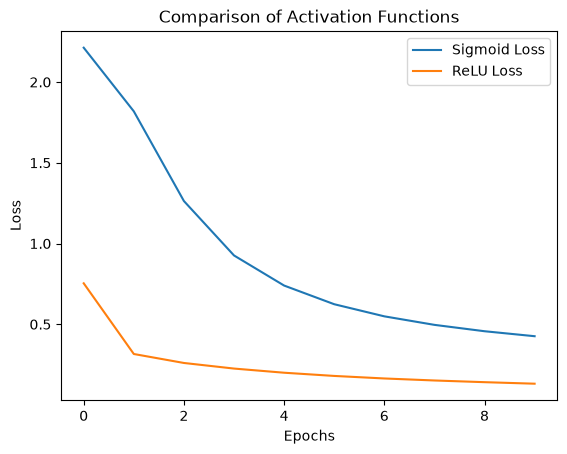

In [6]:
# Plotting Loss
plt.plot(history_sigmoid['loss'], label='Sigmoid Loss')
plt.plot(history_relu['loss'], label='ReLU Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Comparison of Activation Functions')
plt.show()